### Creating data to view and fit

In [1]:
from  sklearn.datasets import make_circles

# Make 1000 examples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [2]:
# Check out features
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [3]:
# Check the labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0], dtype=int64)

Visualizing our created data

In [4]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:, 0], "X1":X[:, 1], "label":y})
circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


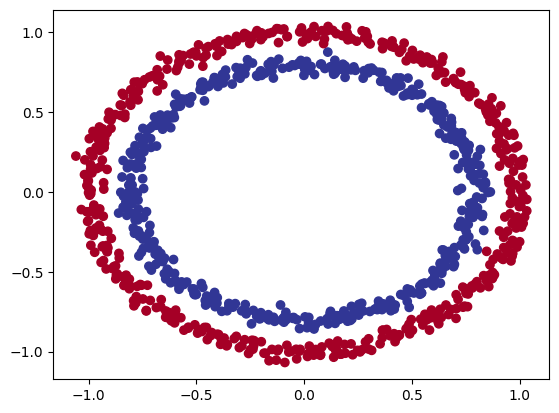

In [5]:
# Visuallize with a plot
import matplotlib.pyplot as plt 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

### Input and output shapes

In [6]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0], dtype=int64)

In [8]:
# how many samples we're working 
len(X), len(y)

(1000, 1000)

In [9]:
# View the first example of features and labels
X[5], y[5]

(array([-0.47964637,  0.67643477]), 1)

### Steps in modelling

In [10]:
import tensorflow as tf

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model using the Sequential API
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])

# 3. Fit the model 
model_1.fit(X, y, epochs=5)



Epoch 1/5


32/32 [==============================] - 1s 2ms/step - loss: 5.9405 - accuracy: 0.4830
Epoch 2/5
32/32 [==============================] - 0s 1ms/step - loss: 4.9436 - accuracy: 0.5170
Epoch 3/5
32/32 [==============================] - 0s 1ms/step - loss: 4.1366 - accuracy: 0.5220
Epoch 4/5
32/32 [==============================] - 0s 1ms/step - loss: 3.9777 - accuracy: 0.5190
Epoch 5/5
32/32 [==============================] - 0s 1ms/step - loss: 3.6992 - accuracy: 0.4960


In [11]:
# Let's try and improve our model by training for longer
model_1.fit(X, y, epochs=200, verbose=0)

In [12]:
# Evaluation
model_1.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6935 - accuracy: 0.5000


[0.6934831142425537, 0.5]

In [13]:
# let's add extra layer

# Set the random seed
tf.random.set_seed(42)

# 1. Create a model, this time with 2 layers
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.SGD(),
               metrics=["accuracy"])

# 3. Fit the model
model_2.fit(X, y, epochs=100, verbose=0)

In [14]:
# 4. Evaluate the model
model_2.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6936 - accuracy: 0.5000


[0.6936224699020386, 0.5]

### Improving our model

In [15]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model (this time 3 layers)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 3. Fit the model
model_3.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 2.9618 - accuracy: 0.4630
Epoch 2/100
32/32 [==============================] - 0s 2ms/step - loss: 0.7258 - accuracy: 0.4930
Epoch 3/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6941 - accuracy: 0.5030
Epoch 4/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6964 - accuracy: 0.4920
Epoch 5/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6972 - accuracy: 0.4620
Epoch 6/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6990 - accuracy: 0.4480
Epoch 7/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6960 - accuracy: 0.5110
Epoch 8/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6938 - accuracy: 0.5220
Epoch 9/100
32/32 [==============================] - 0s 2ms/step - loss: 0.7008 - accuracy: 0.5000
Epoch 10/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6945 - accuracy: 0.4810
Epoch 11/

In [16]:
# 4. Evaluate the model
model_3.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.7012 - accuracy: 0.5110


[0.7011988162994385, 0.5109999775886536]

To visualize our model's predictions, let's create a function `plot_decision_boundary()`, this function will:
* Take in a trained model, features (X) and labels (y)
* Create a meshgrid of the different X values
* Make preditions across the meshgrid
* Plot the predictions as well as a line between zones (where each unique class falss)

In [17]:
import numpy as np

In [18]:
import numpy as np 
def plot_decision_boundary(model, X, y):
    """
    Plots the decision boundary created by a model predicting on X.
    """
    # Define the axis boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Create X value (we're going to make predictions on these)
    x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together
    
    # Make predictions
    y_pred = model.predict(x_in)
    
    # Check for multi-class
    if len(y_pred[0]) > 1:
        print("doing multiclass classification")
        # We have to reshape our prediction to get them ready for plotting
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("doing binary classification")
        y_pred = np.round(y_pred).reshape(xx.shape)
        
    # Plot the decision boundary
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

313/313 [==============================] - 0s 1ms/step
doing binary classification


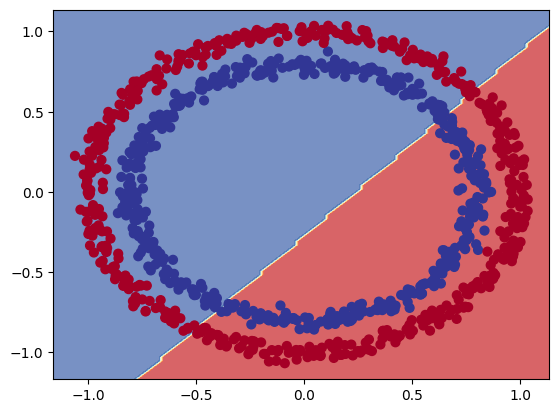

In [19]:
# Check out the predictions our model is making
plot_decision_boundary(model=model_3,
                       X=X,
                       y=y)

### The missing piece : Non Linearity

In [20]:
# Set tje random seed
tf.random.set_seed(42)

# 1. Create the model
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear)
])

# 2. Compile the model
model_4.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_4.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 1ms/step - loss: 5.6351 - accuracy: 0.4820
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 5.5838 - accuracy: 0.4810
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 5.5665 - accuracy: 0.4800
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 5.5616 - accuracy: 0.4810
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 5.5584 - accuracy: 0.4810
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 5.5330 - accuracy: 0.4800
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 5.4918 - accuracy: 0.4820
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 5.4518 - accuracy: 0.4800
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 5.3957 - accuracy: 0.4790
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 5.3324 - accuracy: 0.4800
Epoch 11/

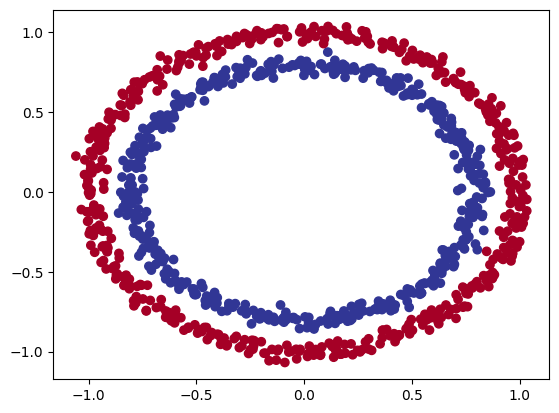

In [21]:
# Check out our data 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

313/313 [==============================] - 0s 1ms/step
doing binary classification


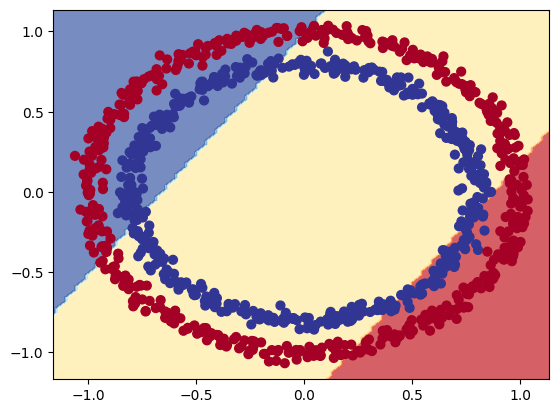

In [22]:
# Check the decision boundary for our latest model
plot_decision_boundary(model=model_4,
                       X=X,
                       y=y)

### let's try build our first neural network with a non-linear activation function

In [23]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model with a non-linear activation
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)
])

# 2. Compile the model
model_5.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_5.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 4.3462 - accuracy: 0.4670
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 4.2708 - accuracy: 0.4680
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 4.2121 - accuracy: 0.4680
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 4.1659 - accuracy: 0.4660
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 4.1444 - accuracy: 0.4680
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 4.1114 - accuracy: 0.4680
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 4.0283 - accuracy: 0.4660
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 3.9029 - accuracy: 0.4630
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 3.7759 - accuracy: 0.4660
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 3.6385 - accuracy: 0.4660
Epoch 11/

In [24]:
# Time to replicate the multi-layer neural network from TensorFLow playground

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_6.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_6.fit(X, y, epochs=250)

Epoch 1/250
32/32 [==============================] - 1s 2ms/step - loss: 4.6672 - accuracy: 0.5000
Epoch 2/250
32/32 [==============================] - 0s 2ms/step - loss: 4.1008 - accuracy: 0.5000
Epoch 3/250
32/32 [==============================] - 0s 2ms/step - loss: 3.6558 - accuracy: 0.5000
Epoch 4/250
32/32 [==============================] - 0s 2ms/step - loss: 3.1026 - accuracy: 0.5000
Epoch 5/250
32/32 [==============================] - 0s 2ms/step - loss: 1.5291 - accuracy: 0.5000
Epoch 6/250
32/32 [==============================] - 0s 2ms/step - loss: 0.8854 - accuracy: 0.5000
Epoch 7/250
32/32 [==============================] - 0s 2ms/step - loss: 0.8335 - accuracy: 0.5000
Epoch 8/250
32/32 [==============================] - 0s 2ms/step - loss: 0.8041 - accuracy: 0.4890
Epoch 9/250
32/32 [==============================] - 0s 2ms/step - loss: 0.7852 - accuracy: 0.4510
Epoch 10/250
32/32 [==============================] - 0s 1ms/step - loss: 0.7719 - accuracy: 0.4590
Epoch 11/

In [25]:
# Evaluate the model
model_6.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.2621 - accuracy: 0.8670


[0.26206669211387634, 0.8669999837875366]

313/313 [==============================] - 0s 1ms/step
doing binary classification


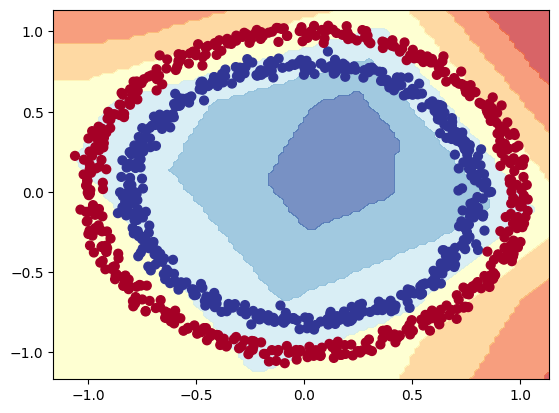

In [26]:
plot_decision_boundary(model=model_6,
                       X=X,
                       y=y)

In [27]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_7.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

# 3. Fit the model
model_7.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 0.6921 - accuracy: 0.5010
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6918 - accuracy: 0.4990
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6915 - accuracy: 0.5000
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6914 - accuracy: 0.5020
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6912 - accuracy: 0.5220
Epoch 6/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6910 - accuracy: 0.5330
Epoch 7/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6906 - accuracy: 0.5340
Epoch 8/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6905 - accuracy: 0.5270
Epoch 9/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6901 - accuracy: 0.5330
Epoch 10/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6898 - accuracy: 0.5170
Epoch 11/

In [28]:
# 4. Evalute the model
model_7.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.4840 - accuracy: 0.8210


[0.4840385913848877, 0.8209999799728394]

313/313 [==============================] - 0s 1ms/step
doing binary classification


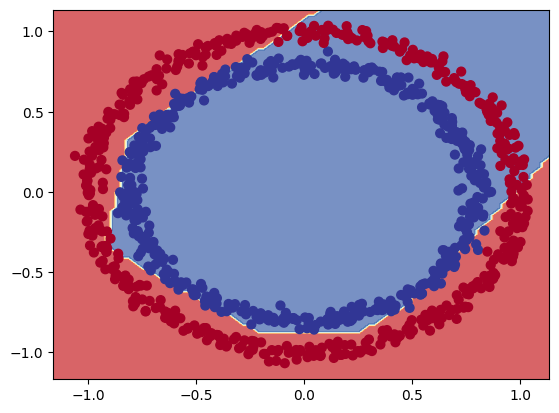

In [29]:
# Let's visualize our model_7
plot_decision_boundary(model_7, X, y)

In [30]:
# Split the dataset into train and test
X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [31]:
# Let's recreate a model to fit on the training data and evaluate on the testing data

# Set random seed
tf.random.set_seed(42)

# 1. Create the model (same as model_7)
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid") 
])

# 2. Compile the model
model_8.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["accuracy"])

# 3. Fit the model
history = model_8.fit(X_train, y_train, epochs=25)

Epoch 1/25
25/25 [==============================] - 1s 2ms/step - loss: 0.6910 - accuracy: 0.5088
Epoch 2/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6869 - accuracy: 0.5437
Epoch 3/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6822 - accuracy: 0.5525
Epoch 4/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6771 - accuracy: 0.5450
Epoch 5/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6699 - accuracy: 0.5825
Epoch 6/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6577 - accuracy: 0.5800
Epoch 7/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6385 - accuracy: 0.7250
Epoch 8/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6185 - accuracy: 0.7025
Epoch 9/25
25/25 [==============================] - 0s 1ms/step - loss: 0.5822 - accuracy: 0.7287
Epoch 10/25
25/25 [==============================] - 0s 2ms/step - loss: 0.5311 - accuracy: 0.7850
Epoch 11/25
25/25 [

In [32]:
# 4. Evaluate the model
model_8.evaluate(X_test, y_test)

7/7 [==============================] - 0s 2ms/step - loss: 0.1865 - accuracy: 0.9600


[0.1865123212337494, 0.9599999785423279]

313/313 [==============================] - 0s 1ms/step
doing binary classification
313/313 [==============================] - 0s 1ms/step
doing binary classification


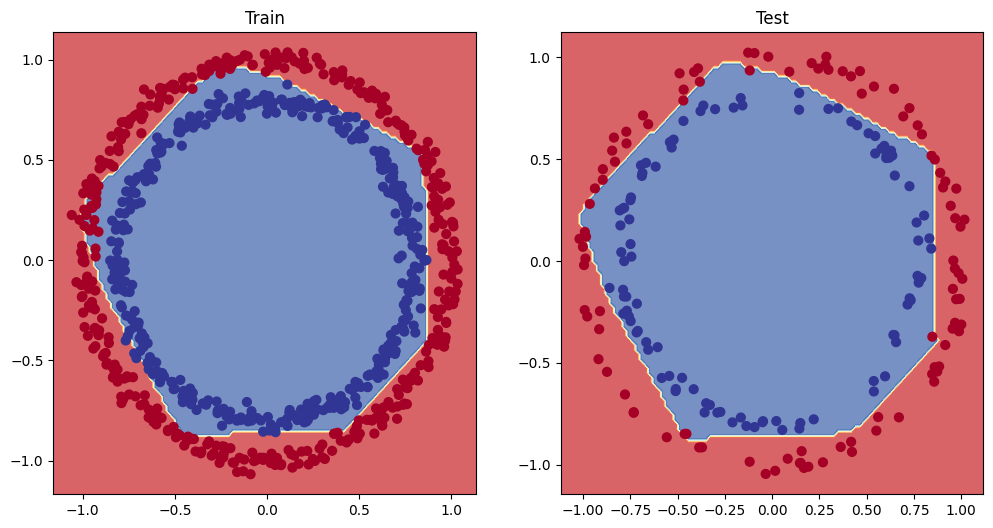

In [33]:
# Plot the decision boundaries for the training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_8, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_8, X_test, y_test)
plt.show()

### Plotting loss curve

In [34]:
# Convert the history object into a DataFrame
pd.DataFrame(history.history)

,loss,accuracy
0,0.690996,0.50875
1,0.686928,0.54375
2,0.682154,0.55250
3,0.677092,0.54500
4,0.669881,0.58250
5,0.657730,0.58000
6,0.638450,0.72500
7,0.618478,0.70250
8,0.582220,0.72875
9,0.531080,0.78500


Text(0.5, 1.0, 'Model_8 loss curves')

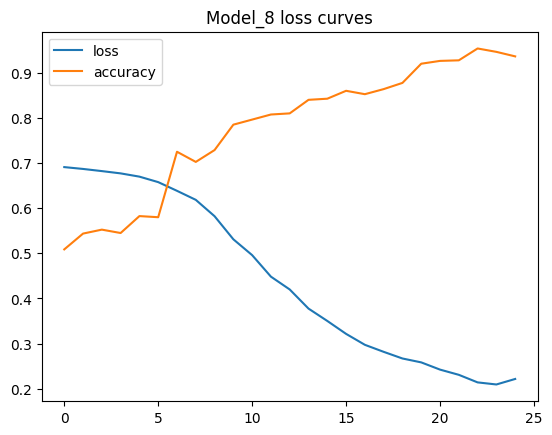

In [35]:
# Plot the loss curves
pd.DataFrame(history.history).plot()
plt.title("Model_8 loss curves")

## Finding the best learining rate

In [36]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model (same as model_8)
model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_9.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

# Create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

# 3. Fit the model (passing lr_scheduler callback)
history_9 = model_9.fit(X_train,
                        y_train,
                        epochs=100,
                        callbacks=[lr_scheduler])

Epoch 1/100
25/25 [==============================] - 1s 2ms/step - loss: 0.6887 - accuracy: 0.5200 - lr: 1.0000e-04
Epoch 2/100
25/25 [==============================] - 0s 2ms/step - loss: 0.6886 - accuracy: 0.5150 - lr: 1.1220e-04
Epoch 3/100
25/25 [==============================] - 0s 1ms/step - loss: 0.6885 - accuracy: 0.5150 - lr: 1.2589e-04
Epoch 4/100
25/25 [==============================] - 0s 2ms/step - loss: 0.6884 - accuracy: 0.5163 - lr: 1.4125e-04
Epoch 5/100
25/25 [==============================] - 0s 2ms/step - loss: 0.6883 - accuracy: 0.5138 - lr: 1.5849e-04
Epoch 6/100
25/25 [==============================] - 0s 1ms/step - loss: 0.6882 - accuracy: 0.5138 - lr: 1.7783e-04
Epoch 7/100
25/25 [==============================] - 0s 1ms/step - loss: 0.6881 - accuracy: 0.5138 - lr: 1.9953e-04
Epoch 8/100
25/25 [==============================] - 0s 2ms/step - loss: 0.6880 - accuracy: 0.5150 - lr: 2.2387e-04
Epoch 9/100
25/25 [==============================] - 0s 2ms/step - loss:

<Axes: xlabel='epochs'>

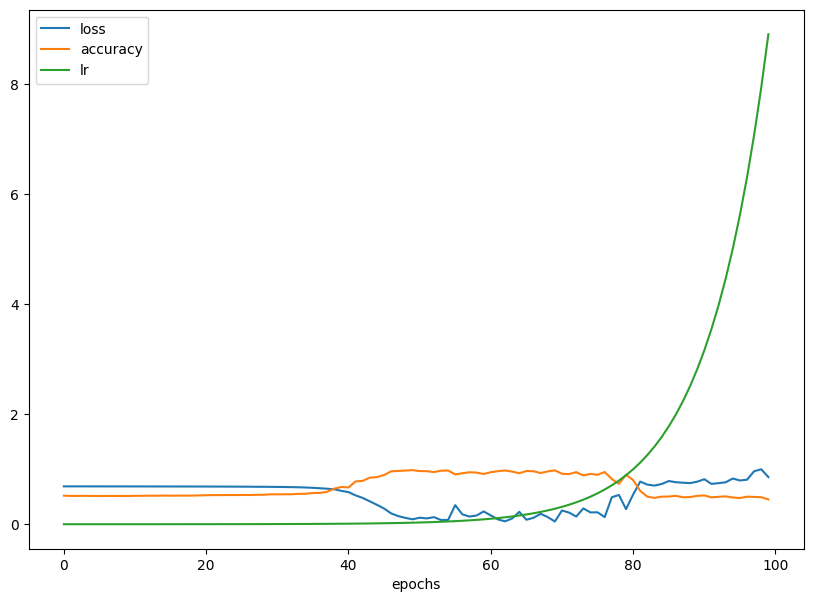

In [37]:
# Checout the history
pd.DataFrame(history_9.history).plot(figsize=(10, 7), xlabel="epochs")

Text(0.5, 1.0, 'Learning rate vs. Loss')

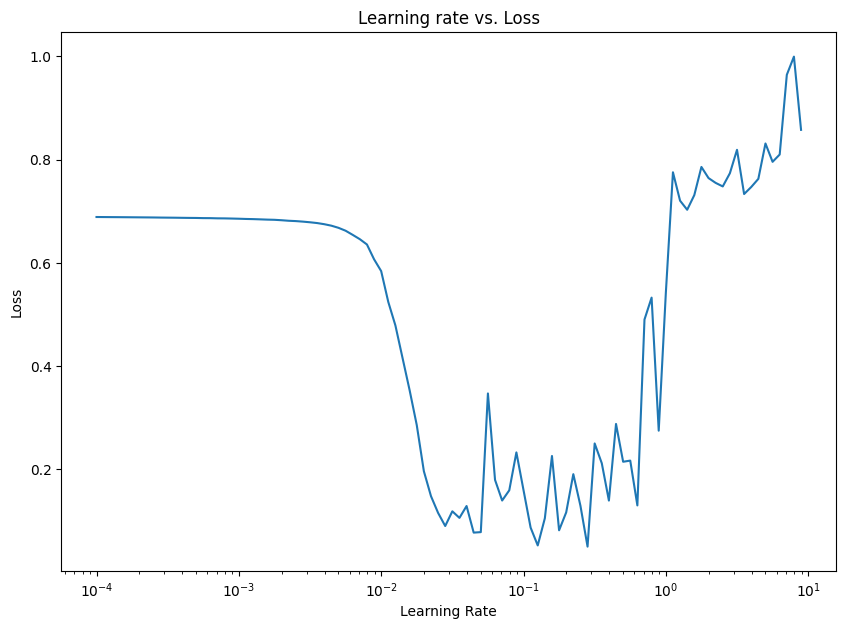

In [38]:
# Plot the learning rate versus the loss
lrs = 1e-4 * (10 ** (tf.range(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_9.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs. Loss")

In [41]:
# Let's try using a higher ideal learning rate with the same model as before

# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model with the ideal learning rate
model_10.compile(loss="binary_crossentropy",
                   optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
                   metrics=["accuracy"])

# Fit the model for 20 epochs (5 less than before)
history_10 = model_10.fit(X_train, y_train, epochs=20)

Epoch 1/20
25/25 [==============================] - 1s 3ms/step - loss: 0.7001 - accuracy: 0.4863
Epoch 2/20
25/25 [==============================] - 0s 2ms/step - loss: 0.6894 - accuracy: 0.4825
Epoch 3/20
25/25 [==============================] - 0s 2ms/step - loss: 0.6827 - accuracy: 0.5238
Epoch 4/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6758 - accuracy: 0.5700
Epoch 5/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6548 - accuracy: 0.5987
Epoch 6/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6249 - accuracy: 0.6112
Epoch 7/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6169 - accuracy: 0.6338
Epoch 8/20
25/25 [==============================] - 0s 1ms/step - loss: 0.5931 - accuracy: 0.6662
Epoch 9/20
25/25 [==============================] - 0s 1ms/step - loss: 0.5770 - accuracy: 0.6700
Epoch 10/20
25/25 [==============================] - 0s 1ms/step - loss: 0.5563 - accuracy: 0.6913
Epoch 11/20
25/25 [

In [42]:
# 4. Evaluate model_10 on the test dataset
model_10.evaluate(X_test, y_test)

7/7 [==============================] - 0s 2ms/step - loss: 0.3999 - accuracy: 0.8050


[0.3999200463294983, 0.8050000071525574]

313/313 [==============================] - 0s 1ms/step
doing binary classification
313/313 [==============================] - 0s 1ms/step
doing binary classification


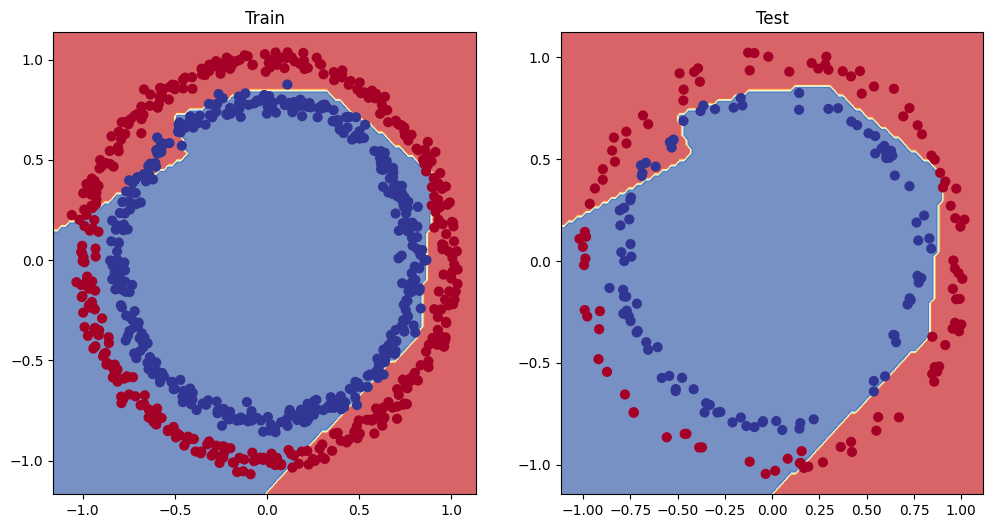

In [44]:
# plot the decision boundaries for the training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_10, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_10, X_test, y_test)
plt.show()